# EDA TSDB depuis `tsdb_full_dump.sql`

Objectif : explorer les donnees temporelles du dump SQL sans restaurer la base au debut.

On va faire les etapes suivantes :

1. Lire les tables utiles du dump SQL.
2. Reconstruire les DataFrames `sensor_data`, `sensor`, `server`.
3. Joindre les mesures avec leurs labels techniques : `CPU_TEMP`, `FAN_SPEED_1`, etc.
4. Verifier la periode, le volume et les types de capteurs.
5. Calculer des statistiques descriptives.
6. Visualiser temperature CPU et vitesse des ventilateurs.
7. Creer des premiers labels metier simples.

## 0. Installer les librairies si necessaire

Lance cette cellule seulement si `pandas` ou `matplotlib` ne sont pas disponibles dans ton kernel.

In [ ]:
# A lancer une seule fois si besoin
# %pip install pandas matplotlib

## 1. Importer les librairies et localiser le dump

In [2]:
from pathlib import Path
from io import StringIO

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

DUMP_PATH = Path("../tsdb_full_dump.sql")
assert DUMP_PATH.exists(), f"Dump introuvable: {DUMP_PATH.resolve()}"

DUMP_PATH.resolve()

PosixPath('/mnt/c/Users/tanjo/projetcs/iot-data-stream/tsdb_full_dump.sql')

## 2. Lire les blocs `COPY` du dump

Le dump PostgreSQL contient les donnees sous forme de blocs :

```sql
COPY public.sensor_data (...) FROM stdin;
...
\.
```

On va extraire ces blocs et les convertir en DataFrames.

In [3]:
def read_copy_table(dump_path: Path, table_name: str) -> pd.DataFrame:
    start = f"COPY public.{table_name} ("
    in_block = False
    columns = None
    rows = []

    with dump_path.open("r", encoding="utf-8") as file:
        for raw_line in file:
            line = raw_line.rstrip("\n")

            if not in_block and line.startswith(start):
                in_block = True
                columns_part = line.split("(", 1)[1].split(")", 1)[0]
                columns = [col.strip().strip('"') for col in columns_part.split(",")]
                continue

            if in_block:
                if line == r"\.":
                    break
                rows.append([None if value == r"\N" else value for value in line.split("\t")])

    if columns is None:
        raise ValueError(f"Table non trouvee dans le dump: {table_name}")

    return pd.DataFrame(rows, columns=columns)


sensor_data = read_copy_table(DUMP_PATH, "sensor_data")
sensor = read_copy_table(DUMP_PATH, "sensor")
server = read_copy_table(DUMP_PATH, "server")
fan = read_copy_table(DUMP_PATH, "fan")

sensor_data.shape, sensor.shape, server.shape, fan.shape

((23650, 4), (50, 6), (10, 8), (40, 8))

## 3. Nettoyer les types de colonnes

Au chargement depuis le dump, tout arrive comme du texte. On convertit les dates, les identifiants et les valeurs numeriques.

In [4]:
sensor_data["id"] = sensor_data["id"].astype(int)
sensor_data["time"] = pd.to_datetime(sensor_data["time"])
sensor_data["sensor_id"] = sensor_data["sensor_id"].astype(int)
sensor_data["value"] = sensor_data["value"].astype(float)

sensor["sensor_id"] = sensor["sensor_id"].astype(int)
sensor["server_id"] = sensor["server_id"].astype(int)
sensor["last_value"] = pd.to_numeric(sensor["last_value"], errors="coerce")
sensor["created_at"] = pd.to_datetime(sensor["created_at"])

server["server_id"] = server["server_id"].astype(int)
server["cluster_id"] = server["cluster_id"].astype(int)
server["config_id"] = pd.to_numeric(server["config_id"], errors="coerce")
server["is_master"] = server["is_master"].map({"t": True, "f": False})
server["base_consumption_offset"] = pd.to_numeric(server["base_consumption_offset"], errors="coerce")
server["created_at"] = pd.to_datetime(server["created_at"])

fan["fan_id"] = fan["fan_id"].astype(int)
fan["server_id"] = fan["server_id"].astype(int)
fan["speed_percent"] = fan["speed_percent"].astype(int)

sensor_data.head()

,id,time,sensor_id,value
0,1,2026-05-18,1,12.0
1,2,2026-05-18,6,12.0
2,3,2026-05-18,11,20.0
3,4,2026-05-18,16,20.0
4,5,2026-05-18,31,20.0


## 4. Creer la table d'analyse principale

`sensor_data` contient seulement `time`, `sensor_id`, `value`.

Pour comprendre une mesure, il faut ajouter :

- `sensor_type` : temperature, vitesse ventilateur, charge, puissance
- `unit` : degres, %, watts
- `hostname` : serveur concerne
- `is_master` : role du serveur

In [5]:
telemetry = (
    sensor_data
    .merge(sensor[["sensor_id", "server_id", "sensor_type", "unit"]], on="sensor_id", how="left")
    .merge(server[["server_id", "hostname", "is_master"]], on="server_id", how="left")
)

telemetry.head(10)

,id,time,sensor_id,value,server_id,sensor_type,unit,hostname,is_master
0,1,2026-05-18,1,12.0,1,LOAD,%,marseille-marseille-zone-01-master-01,True
1,2,2026-05-18,6,12.0,2,LOAD,%,marseille-marseille-zone-01-master-02,True
2,3,2026-05-18,11,20.0,3,LOAD,%,marseille-marseille-zone-01-worker-01,False
3,4,2026-05-18,16,20.0,4,LOAD,%,marseille-marseille-zone-01-worker-02,False
4,5,2026-05-18,31,20.0,7,LOAD,%,marseille-marseille-zone-01-worker-05,False
5,6,2026-05-18,21,20.0,5,LOAD,%,marseille-marseille-zone-01-worker-03,False
6,7,2026-05-18,36,20.0,8,LOAD,%,marseille-marseille-zone-01-worker-06,False
7,8,2026-05-18,41,20.0,9,LOAD,%,marseille-marseille-zone-01-worker-07,False
8,9,2026-05-18,26,20.0,6,LOAD,%,marseille-marseille-zone-01-worker-04,False
9,10,2026-05-18,46,20.0,10,LOAD,%,marseille-marseille-zone-01-worker-08,False


## 5. Vue globale du dataset

Questions de base : combien de mesures, quelle periode, combien de serveurs, combien de capteurs ?

In [6]:
overview = {
    "nb_mesures": len(telemetry),
    "debut": telemetry["time"].min(),
    "fin": telemetry["time"].max(),
    "nb_serveurs": telemetry["server_id"].nunique(),
    "nb_capteurs": telemetry["sensor_id"].nunique(),
    "types_capteurs": sorted(telemetry["sensor_type"].unique()),
}

overview

{'nb_mesures': 23650,
 'debut': Timestamp('2026-05-18 00:00:00'),
 'fin': Timestamp('2026-06-06 17:00:00'),
 'nb_serveurs': 10,
 'nb_capteurs': 50,
 'types_capteurs': ['CPU_TEMP',
  'FAN_SPEED_1',
  'FAN_SPEED_2',
  'LOAD',
  'TOTAL_POWER']}

## 5 bis. Distinguer ventilateurs physiques et capteurs de vitesse

Important : la table `fan` contient les ventilateurs physiques. La table `sensor` contient les capteurs qui mesurent ou exposent des valeurs.

Donc `FAN_SPEED_1` et `FAN_SPEED_2` ne veulent pas dire qu'il y a seulement deux ventilateurs dans toute l'infrastructure. Ce sont deux canaux de mesure de vitesse par serveur.

In [7]:
physical_fans_by_server = fan.groupby("server_id").agg(
    nb_physical_fans=("fan_id", "count"),
    avg_current_speed_percent=("speed_percent", "mean"),
).reset_index().merge(server[["server_id", "hostname"]], on="server_id", how="left")

speed_sensors_by_server = sensor[sensor["sensor_type"].str.startswith("FAN_SPEED")].groupby("server_id").agg(
    nb_fan_speed_sensors=("sensor_id", "count"),
    sensor_types=("sensor_type", lambda values: sorted(values.tolist())),
).reset_index().merge(server[["server_id", "hostname"]], on="server_id", how="left")

physical_fans_by_server.merge(
    speed_sensors_by_server,
    on=["server_id", "hostname"],
    how="left",
)

,server_id,nb_physical_fans,avg_current_speed_percent,hostname,nb_fan_speed_sensors,sensor_types
0,1,4,35.0,marseille-marseille-zone-01-master-01,2,"[FAN_SPEED_1, FAN_SPEED_2]"
1,2,4,35.0,marseille-marseille-zone-01-master-02,2,"[FAN_SPEED_1, FAN_SPEED_2]"
2,3,4,35.0,marseille-marseille-zone-01-worker-01,2,"[FAN_SPEED_1, FAN_SPEED_2]"
3,4,4,35.0,marseille-marseille-zone-01-worker-02,2,"[FAN_SPEED_1, FAN_SPEED_2]"
4,5,4,35.0,marseille-marseille-zone-01-worker-03,2,"[FAN_SPEED_1, FAN_SPEED_2]"
5,6,4,35.0,marseille-marseille-zone-01-worker-04,2,"[FAN_SPEED_1, FAN_SPEED_2]"
6,7,4,35.0,marseille-marseille-zone-01-worker-05,2,"[FAN_SPEED_1, FAN_SPEED_2]"
7,8,4,35.0,marseille-marseille-zone-01-worker-06,2,"[FAN_SPEED_1, FAN_SPEED_2]"
8,9,4,35.0,marseille-marseille-zone-01-worker-07,2,"[FAN_SPEED_1, FAN_SPEED_2]"
9,10,4,35.0,marseille-marseille-zone-01-worker-08,2,"[FAN_SPEED_1, FAN_SPEED_2]"


## 6. Nombre de mesures par type de capteur

On verifie si les capteurs ont tous le meme nombre de points. Si ce n'est pas le cas, il peut y avoir des trous ou des capteurs silencieux.

In [8]:
telemetry.groupby(["sensor_type", "unit"]).agg(
    nb_points=("value", "size"),
    nb_capteurs=("sensor_id", "nunique"),
    nb_serveurs=("server_id", "nunique"),
    min_time=("time", "min"),
    max_time=("time", "max"),
).reset_index().sort_values("sensor_type")

,sensor_type,unit,nb_points,nb_capteurs,nb_serveurs,min_time,max_time
0,CPU_TEMP,°C,4730,10,10,2026-05-18,2026-06-06 17:00:00
1,FAN_SPEED_1,%,4730,10,10,2026-05-18,2026-06-06 17:00:00
2,FAN_SPEED_2,%,4730,10,10,2026-05-18,2026-06-06 17:00:00
3,LOAD,%,4730,10,10,2026-05-18,2026-06-06 17:00:00
4,TOTAL_POWER,W,4730,10,10,2026-05-18,2026-06-06 17:00:00


## 7. Statistiques descriptives

Ici on cherche les ordres de grandeur : minimum, moyenne, maximum, ecart-type.

In [9]:
stats_by_type = telemetry.groupby(["sensor_type", "unit"])["value"].agg(
    count="count",
    min="min",
    mean="mean",
    median="median",
    max="max",
    std="std",
).reset_index()

stats_by_type

,sensor_type,unit,count,min,mean,median,max,std
0,CPU_TEMP,°C,4730,19.69,25.569074,25.84,61.66,4.552384
1,FAN_SPEED_1,%,4730,20.00,58.481818,60.00,95.00,22.699674
2,FAN_SPEED_2,%,4730,20.00,58.481818,60.00,95.00,22.699674
3,LOAD,%,4730,12.00,24.670106,20.00,100.00,11.982740
4,TOTAL_POWER,W,4730,171.60,236.500440,216.60,507.00,45.876769


## 8. Comparer les serveurs

On regarde si un serveur chauffe plus que les autres, ou si ses ventilateurs tournent differemment.

In [10]:
server_stats = telemetry.groupby(["hostname", "is_master", "sensor_type", "unit"])["value"].agg(
    count="count",
    min="min",
    mean="mean",
    max="max",
).reset_index()

server_stats.sort_values(["sensor_type", "mean"], ascending=[True, False]).head(30)

,hostname,is_master,sensor_type,unit,count,min,mean,max
10,marseille-marseille-zone-01-worker-01,False,CPU_TEMP,°C,473,19.72,28.025793,61.66
15,marseille-marseille-zone-01-worker-02,False,CPU_TEMP,°C,473,19.70,26.763932,53.41
30,marseille-marseille-zone-01-worker-05,False,CPU_TEMP,°C,473,19.70,26.400634,46.70
45,marseille-marseille-zone-01-worker-08,False,CPU_TEMP,°C,473,19.70,26.398901,46.51
40,marseille-marseille-zone-01-worker-07,False,CPU_TEMP,°C,473,19.70,26.397040,46.64
25,marseille-marseille-zone-01-worker-04,False,CPU_TEMP,°C,473,19.72,26.396998,46.68
35,marseille-marseille-zone-01-worker-06,False,CPU_TEMP,°C,473,19.69,26.390507,46.68
20,marseille-marseille-zone-01-worker-03,False,CPU_TEMP,°C,473,19.71,26.366829,46.65
0,marseille-marseille-zone-01-master-01,True,CPU_TEMP,°C,473,19.69,21.279535,26.88
5,marseille-marseille-zone-01-master-02,True,CPU_TEMP,°C,473,19.70,21.270571,29.40


## 9. Visualiser la temperature CPU moyenne dans le temps

On commence par une courbe simple : moyenne horaire de la temperature CPU.

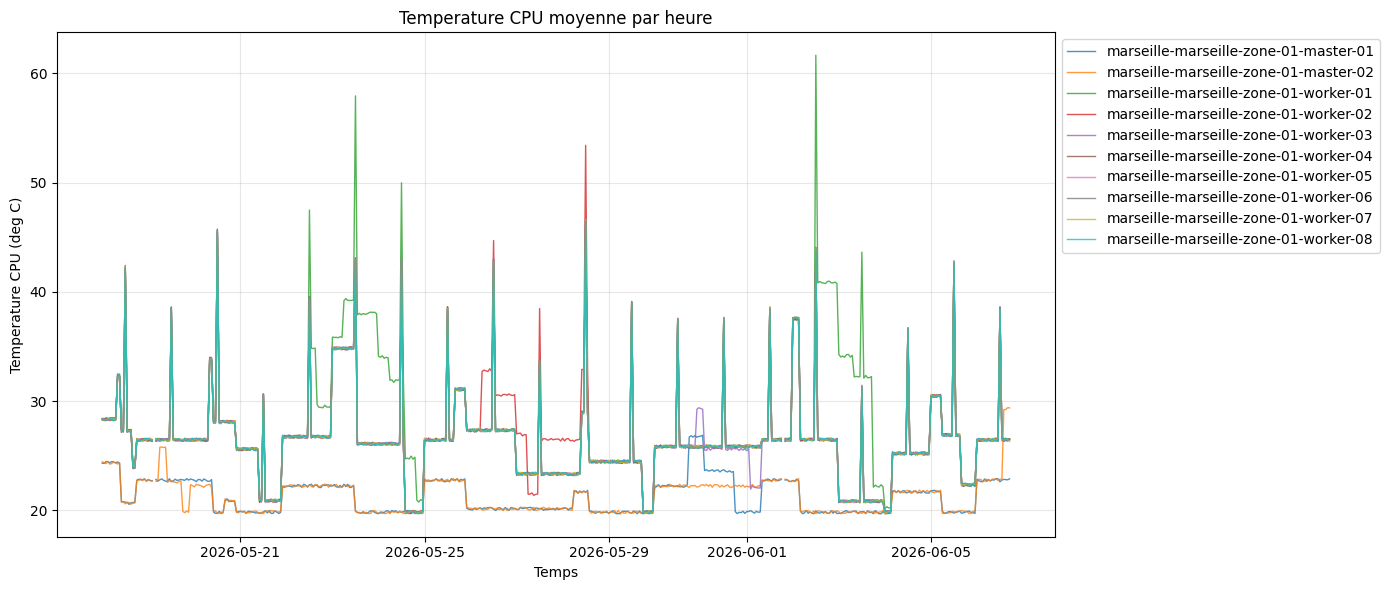

In [11]:
cpu_hourly = (
    telemetry[telemetry["sensor_type"] == "CPU_TEMP"]
    .set_index("time")
    .groupby("hostname")["value"]
    .resample("1h")
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))
for hostname, group in cpu_hourly.groupby("hostname"):
    plt.plot(group["time"], group["value"], linewidth=1, alpha=0.8, label=hostname)

plt.title("Temperature CPU moyenne par heure")
plt.xlabel("Temps")
plt.ylabel("Temperature CPU (deg C)")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Visualiser les vitesses de ventilateur

Les vitesses de ventilateur sont en pourcentage. Ici on compare les deux capteurs de vitesse `FAN_SPEED_1` et `FAN_SPEED_2`.

Dans le code de simulation, ces capteurs recoivent la vitesse moyenne des ventilateurs physiques actifs du serveur, pas forcement la vitesse individuelle de chaque ventilateur physique.

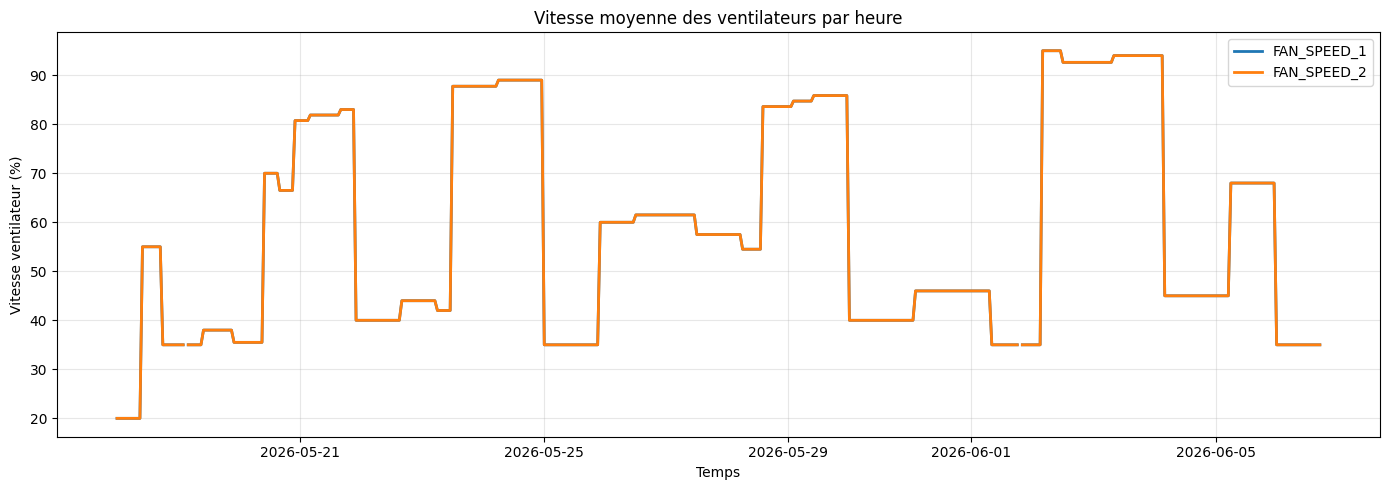

In [12]:
fan_hourly = (
    telemetry[telemetry["sensor_type"].isin(["FAN_SPEED_1", "FAN_SPEED_2"])]
    .set_index("time")
    .groupby("sensor_type")["value"]
    .resample("1h")
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 5))
for sensor_type, group in fan_hourly.groupby("sensor_type"):
    plt.plot(group["time"], group["value"], linewidth=2, label=sensor_type)

plt.title("Vitesse moyenne des ventilateurs par heure")
plt.xlabel("Temps")
plt.ylabel("Vitesse ventilateur (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Creer des labels metier simples pour la temperature

Ces seuils sont un exemple. Ils doivent etre adaptes a votre contexte metier.

- `< 30` : `normal`
- `30 - 50` : `warning`
- `>= 50` : `critical`

In [ ]:
def label_cpu_temp(value: float) -> str:
    if value < 30:
        return "normal"
    if value < 50:
        return "warning"
    return "critical"


cpu_temp = telemetry[telemetry["sensor_type"] == "CPU_TEMP"].copy()
cpu_temp["temp_label"] = cpu_temp["value"].apply(label_cpu_temp)

cpu_temp["temp_label"].value_counts().rename_axis("label").reset_index(name="nb_points")

,label,nb_points
0,normal,4653
1,warning,76
2,critical,1


## 12. Creer une table large par serveur et timestamp

Pour analyser la relation temperature/ventilateur, c'est plus pratique d'avoir une ligne par serveur et par temps, avec une colonne par type de capteur.

In [14]:
wide = telemetry.pivot_table(
    index=["time", "server_id", "hostname", "is_master"],
    columns="sensor_type",
    values="value",
    aggfunc="mean",
).reset_index()

wide.columns.name = None
wide.head()

,time,server_id,hostname,is_master,CPU_TEMP,FAN_SPEED_1,FAN_SPEED_2,LOAD,TOTAL_POWER
0,2026-05-18,1,marseille-marseille-zone-01-master-01,True,24.315,20.0,20.0,12.0,171.6
1,2026-05-18,2,marseille-marseille-zone-01-master-02,True,24.445,20.0,20.0,12.0,171.6
2,2026-05-18,3,marseille-marseille-zone-01-worker-01,False,28.270,20.0,20.0,20.0,198.0
3,2026-05-18,4,marseille-marseille-zone-01-worker-02,False,28.330,20.0,20.0,20.0,198.0
4,2026-05-18,5,marseille-marseille-zone-01-worker-03,False,28.370,20.0,20.0,20.0,198.0


## 13. Label combine temperature + ventilation

Exemple de lecture metier :

- temperature haute et ventilation basse : `hot_with_low_fan`
- temperature haute et ventilation active : `hot_with_active_fan`
- sinon : `normal_or_mild`

In [15]:
wide["avg_fan_speed"] = wide[["FAN_SPEED_1", "FAN_SPEED_2"]].mean(axis=1)

def label_temp_fan(row) -> str:
    if row["CPU_TEMP"] >= 50 and row["avg_fan_speed"] < 30:
        return "hot_with_low_fan"
    if row["CPU_TEMP"] >= 50 and row["avg_fan_speed"] >= 30:
        return "hot_with_active_fan"
    if row["CPU_TEMP"] >= 30:
        return "warm"
    return "normal"


wide["state_label"] = wide.apply(label_temp_fan, axis=1)
wide["state_label"].value_counts().rename_axis("state_label").reset_index(name="nb_points")

,state_label,nb_points
0,normal,4229
1,warm,488
2,hot_with_active_fan,3


## 14. Regarder les cas les plus chauds

Cette cellule sert a inspecter les lignes les plus importantes pour comprendre les scenarios.

In [16]:
wide.sort_values("CPU_TEMP", ascending=False).head(20)[[
    "time", "hostname", "is_master", "CPU_TEMP", "FAN_SPEED_1", "FAN_SPEED_2", "avg_fan_speed", "LOAD", "TOTAL_POWER", "state_label"
]]

,time,hostname,is_master,CPU_TEMP,FAN_SPEED_1,FAN_SPEED_2,avg_fan_speed,LOAD,TOTAL_POWER,state_label
3702,2026-06-02 12:00:00,marseille-marseille-zone-01-worker-01,False,61.66,71.25,71.25,71.25,100.0,492.75,hot_with_active_fan
1312,2026-05-23 12:00:00,marseille-marseille-zone-01-worker-01,False,57.94,67.50,67.50,67.50,92.0,464.10,hot_with_active_fan
2513,2026-05-28 12:00:00,marseille-marseille-zone-01-worker-02,False,53.41,35.00,35.00,35.00,78.2,399.06,hot_with_active_fan
1552,2026-05-24 12:00:00,marseille-marseille-zone-01-worker-01,False,49.98,80.00,80.00,80.00,92.0,471.60,warm
1072,2026-05-22 12:00:00,marseille-marseille-zone-01-worker-01,False,47.49,40.00,40.00,40.00,50.6,310.98,warm
2512,2026-05-28 12:00:00,marseille-marseille-zone-01-worker-01,False,46.74,60.00,60.00,60.00,78.2,414.06,warm
2516,2026-05-28 12:00:00,marseille-marseille-zone-01-worker-05,False,46.70,60.00,60.00,60.00,78.2,414.06,warm
2515,2026-05-28 12:00:00,marseille-marseille-zone-01-worker-04,False,46.68,60.00,60.00,60.00,78.2,414.06,warm
2517,2026-05-28 12:00:00,marseille-marseille-zone-01-worker-06,False,46.68,60.00,60.00,60.00,78.2,414.06,warm
2514,2026-05-28 12:00:00,marseille-marseille-zone-01-worker-03,False,46.65,60.00,60.00,60.00,78.2,414.06,warm


## 15. Prochaines questions a traiter

Apres cette premiere EDA, les questions naturelles sont :

1. Les temperatures elevees arrivent-elles toujours avec une charge elevee ?
2. Les ventilateurs reagissent-ils correctement quand la temperature monte ?
3. Les serveurs master chauffent-ils differemment des workers ?
4. Y a-t-il des trous dans la serie temporelle ?
5. Les seuils de labels sont-ils coherents avec le scenario simule ?